In [9]:
import os
import zipfile
from pathlib import Path
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append(os.path.dirname(os.path.abspath("")))
from utils.utils import set_seed, get_experiment_id, get_run_dir_full
# set_seed(42)

In [24]:
config_file_name_list = ["config_crc_trainP5_valP1.json", "config_crc_trainP5V_valP1.json", "config_crc_trainP5_valP2.json", "config_crc_trainP5V_valP2.json", "config_crc_trainP5_valP5.json", "config_crc_trainP5V_valP5.json"]
fold_id = 1
epoch = "last"  # "last" or specific epoch number (starting from 0)
gpu_id = 3

graph_combos = ["nonvariant_only", "variant_only", "all"]
patient_to_color = {
    "P1": "blue",
    "P2": "orange",
    "P5": "green",
}

Dataset:

- Manuscript: https://www.nature.com/articles/s41588-025-02193-3#data-availability
- 10x: https://www.10xgenomics.com/platforms/visium/product-family/dataset-human-crc
- 10x (alt): https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-human-crc
- GEO: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE280318
- SRA: https://www.ncbi.nlm.nih.gov/Traces/study/?acc=PRJNA1177833&o=acc_s%3Aa

In [ ]:
os.chdir("../")

## Do more validation

In [ ]:
config_file_name_to_metric_df_dict = {}
for i, config_file_name in enumerate(config_file_name_list):
    print(f"Running validation for file {i+1}/{len(config_file_name_list)}: {config_file_name}...")
    config_file_name_without_ext = config_file_name.split(".")[0]
    run_dir_full = get_run_dir_full(config_file_name, fold_id)
    validation_set = config_file_name.split("_")[-1].split(".")[0][-2:]
    
    train_log_path = f"{run_dir_full}/train_out.txt"
    val_log_path = f"{run_dir_full}/val_{validation_set}_out.txt"
    
    !python inference.py --config_file configs/{config_file_name} --epoch {epoch} --mode val --fold_id {fold_id} --gpu_id {gpu_id} | tee {val_log_path}

    def extract_metrics(log_path, pattern):
        """Return {epoch: value} from log file matching given regex pattern."""
        results = {}
        try:
            with open(log_path) as f:
                for line in f:
                    match = pattern.search(line)
                    if match:
                        epoch = int(match.group(1))
                        value = float(match.group(2))
                        results[epoch] = value
        except FileNotFoundError:
            print(f"File not found: {log_path}")
        return results

    metrics_config = [
        {
            "split": "train",
            "metric": "loss",
            "file": train_log_path,
            "regex": re.compile(r"Epoch\[(\d+)/\d+\],\s*loss:([0-9]*\.?[0-9]+)", re.IGNORECASE),
        },
        {
            "split": "val",
            "metric": "expr_pcc",
            "file": val_log_path,
            "regex": re.compile(r"Epoch\[(\d+)\],\s*PCC\s+mean\s*\(expression(?:\scorrelation)?\):\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
        },
        {
            "split": "val",
            "metric": "celltype_f1",
            "file": val_log_path,
            "regex": re.compile(r"Epoch\[(\d+)\],\s*F1\s*\(cell types\):\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
        },
        {
            "split": "val",
            "metric": "variant_f1",
            "file": val_log_path,
            "regex": re.compile(r"Epoch\[(\d+)\],\s*F1\s*\(variants\):\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
        },
    ]

    df_metrics = pd.DataFrame(metrics_config)
    df_metrics["dict"] = df_metrics.apply(lambda row: extract_metrics(row["file"], row["regex"]), axis=1)

    config_file_name_to_metric_df_dict[config_file_name_without_ext] = df_metrics

## Visualize results

In [21]:
# # dummy data for testing
# import pandas as pd
# import numpy as np

# # Two example DataFrames
# df_trainP5_valP1 = pd.DataFrame([
#     {
#         "split": "train",
#         "metric": "loss",
#         "dict": {1: np.random.rand(), 2: np.random.rand(), 3: np.random.rand()},
#     },
#     {
#         "split": "val",
#         "metric": "f1",
#         "dict": {1: np.random.rand(), 2: np.random.rand(), 3: np.random.rand()},
#     },
# ])

# df_trainP5_valP2 = pd.DataFrame([
#     {
#         "split": "train",
#         "metric": "loss",
#         "dict": {1: np.random.rand(), 2: np.random.rand(), 3: np.random.rand()},
#     },
#     {
#         "split": "val",
#         "metric": "f1",
#         "dict": {1: np.random.rand(), 2: np.random.rand(), 3: np.random.rand()},
#     },
# ])

# df_trainP5V_valP1 = pd.DataFrame([
#     {
#         "split": "train",
#         "metric": "loss",
#         "dict": {1: np.random.rand(), 2: np.random.rand(), 3: np.random.rand()},
#     },
#     {
#         "split": "val",
#         "metric": "f1",
#         "dict": {1: np.random.rand(), 2: np.random.rand(), 3: np.random.rand()},
#     },
# ])

# df_trainP5V_valP2 = pd.DataFrame([
#     {
#         "split": "train",
#         "metric": "loss",
#         "dict": {1: np.random.rand(), 2: np.random.rand(), 3: np.random.rand()},
#     },
#     {
#         "split": "val",
#         "metric": "f1",
#         "dict": {1: np.random.rand(), 2: np.random.rand(), 3: np.random.rand()},
#     },
# ])

# # Combine into dictionary
# config_file_name_to_metric_df_dict = {
#     "config_crc_trainP5_valP1": df_trainP5_valP1,
#     "config_crc_trainP5_valP2": df_trainP5_valP2,
#     "config_crc_trainP5V_valP1": df_trainP5V_valP1,
#     "config_crc_trainP5V_valP2": df_trainP5V_valP2,
# }

# # Show the structure
# for name, df in config_file_name_to_metric_df_dict.items():
#     print(f"\n{name}:\n{df}\n")



config_crc_trainP5_valP1:
   split metric                                               dict
0  train   loss  {1: 0.6495172082779533, 2: 0.9257824598915256,...
1    val     f1  {1: 0.5878301854486387, 2: 0.4507714230324956,...


config_crc_trainP5_valP2:
   split metric                                               dict
0  train   loss  {1: 0.7471592673654703, 2: 0.7467881383301359,...
1    val     f1  {1: 0.5248791446432822, 2: 0.6137453275034102,...


config_crc_trainP5V_valP1:
   split metric                                               dict
0  train   loss  {1: 0.2781097060256398, 2: 0.5756952170690475,...
1    val     f1  {1: 0.5096139209815291, 2: 0.04988522746458168...


config_crc_trainP5V_valP2:
   split metric                                               dict
0  train   loss  {1: 0.8027381314927624, 2: 0.19383405339582183...
1    val     f1  {1: 0.9810442565934329, 2: 0.3718004414007494,...



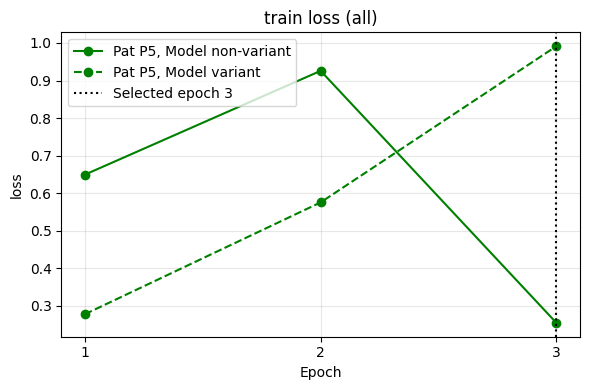

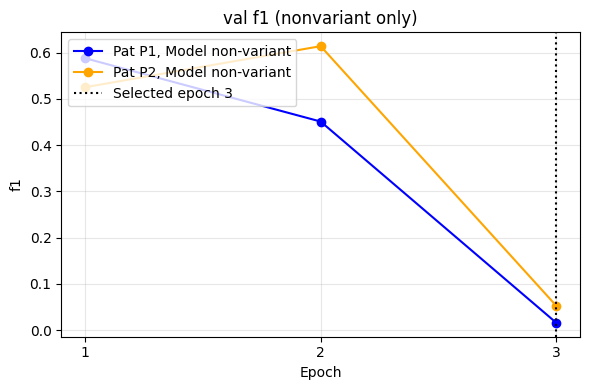

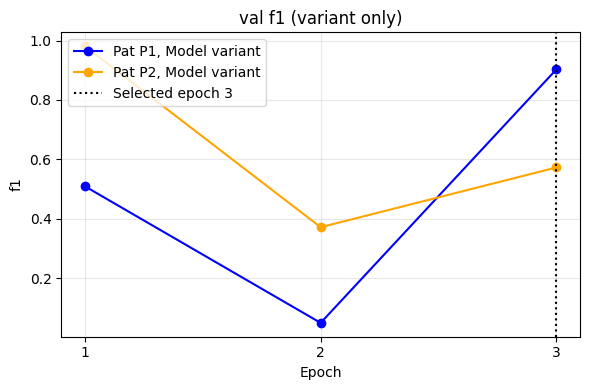

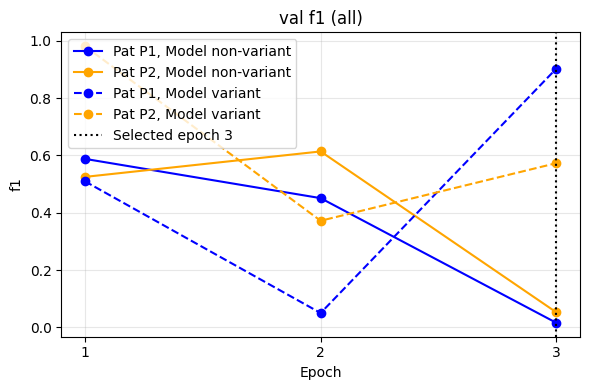

In [ ]:
for _, ref_row in next(iter(config_file_name_to_metric_df_dict.values())).iterrows():
    for graph_combo in graph_combos:
        split, metric = ref_row["split"], ref_row["metric"]
        if split == "train" and graph_combo != "all":  #! hard-coded in the sense that it assumes that I only trained on P5
            continue  # only "all" makes sense for training split
        
        title = f"{split} {metric} ({graph_combo.replace('_', ' ')})"

        plt.figure(figsize=(6, 4))

        recorded_combos = {}
        for config_name, df in config_file_name_to_metric_df_dict.items():
            model_type = "variant" if "P5V" in config_name else "non-variant"  #! hard-coded way of identifying model type from config file name
            if (model_type == "variant" and graph_combo == "nonvariant_only") or (model_type == "non-variant" and graph_combo == "variant_only"):
                continue

            patient = "P5" if split == "train" else config_name[-2:]  #! hard-coded way of identifying patient from config file name, and assuming training is always on P5
            label = f"Pat {patient}, Model {model_type}"

            # avoid duplicate plots
            dict_key = (split, metric, model_type, patient)
            if dict_key in recorded_combos:
                continue
            recorded_combos[dict_key] = True
            
            linestyle = "--" if (graph_combo == "all" and model_type == "variant") else "-"
            row = df[(df["split"] == split) & (df["metric"] == metric)]
            if row.empty or not row.iloc[0]["dict"]:
                print(f"No data for {config_name}: {title}")
                continue

            data = row.iloc[0]["dict"]
            epochs = sorted(data.keys())
            values = [data[e] for e in epochs]

            plt.plot(epochs, values, marker="o", label=label, color=patient_to_color.get(patient, "black"), linestyle=linestyle)
        
        epoch = max(epochs) if epoch == "last" else int(epoch)
        plt.axvline(x=epoch, color="black", linestyle=":", label=f"Selected epoch {epoch}")

        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.xticks(epochs)  # integer ticks
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()
